In [10]:
from surya.layout import LayoutPredictor
from surya.foundation import FoundationPredictor
from surya.settings import settings
from PIL import Image

fp = FoundationPredictor(checkpoint=settings.LAYOUT_MODEL_CHECKPOINT)
lp = LayoutPredictor(fp)

In [11]:
pdf_path = 'rlbook2020.pdf'
from pathlib import Path
Path(pdf_path).exists()

True

In [12]:
import torch
print(torch.cuda.is_available())

True


In [13]:
from PIL import Image, ImageDraw, ImageFont


LABEL_COLORS = {
    "Text": "#d62828",
    "SectionHeader": "#1d4ed8",
    "Picture": "#2b9348",
    "Caption": "#f77f00",
    "PageFooter": "#7b2cbf",
    "PageHeader": "#0f766e",
    "ListItem": "#c1121f",
    "Code": "#9c27b0",
}


def annotate_layout(image, layout_result):
    img = image.convert("RGB").copy()

    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 20)
    except:
        font = ImageFont.load_default()

    for box in layout_result.bboxes:
        x1, y1, x2, y2 = map(int, box.bbox)

        label = str(box.label)
        confidence = float(box.confidence)

        color = LABEL_COLORS.get(label, "#ff0000")

        # bbox
        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline=color,
            width=4,
        )

        # label text
        text = f"{label} {confidence:.2f}"

        text_bbox = draw.textbbox((0, 0), text, font=font)

        text_w = text_bbox[2] - text_bbox[0]
        text_h = text_bbox[3] - text_bbox[1]

        text_x = x1
        text_y = max(0, y1 - text_h - 4)

        # background
        draw.rectangle(
            [
                (text_x, text_y),
                (text_x + text_w + 8, text_y + text_h + 4),
            ],
            fill=color,
        )

        draw.text(
            (text_x + 4, text_y + 2),
            text,
            fill="white",
            font=font,
        )

    return img

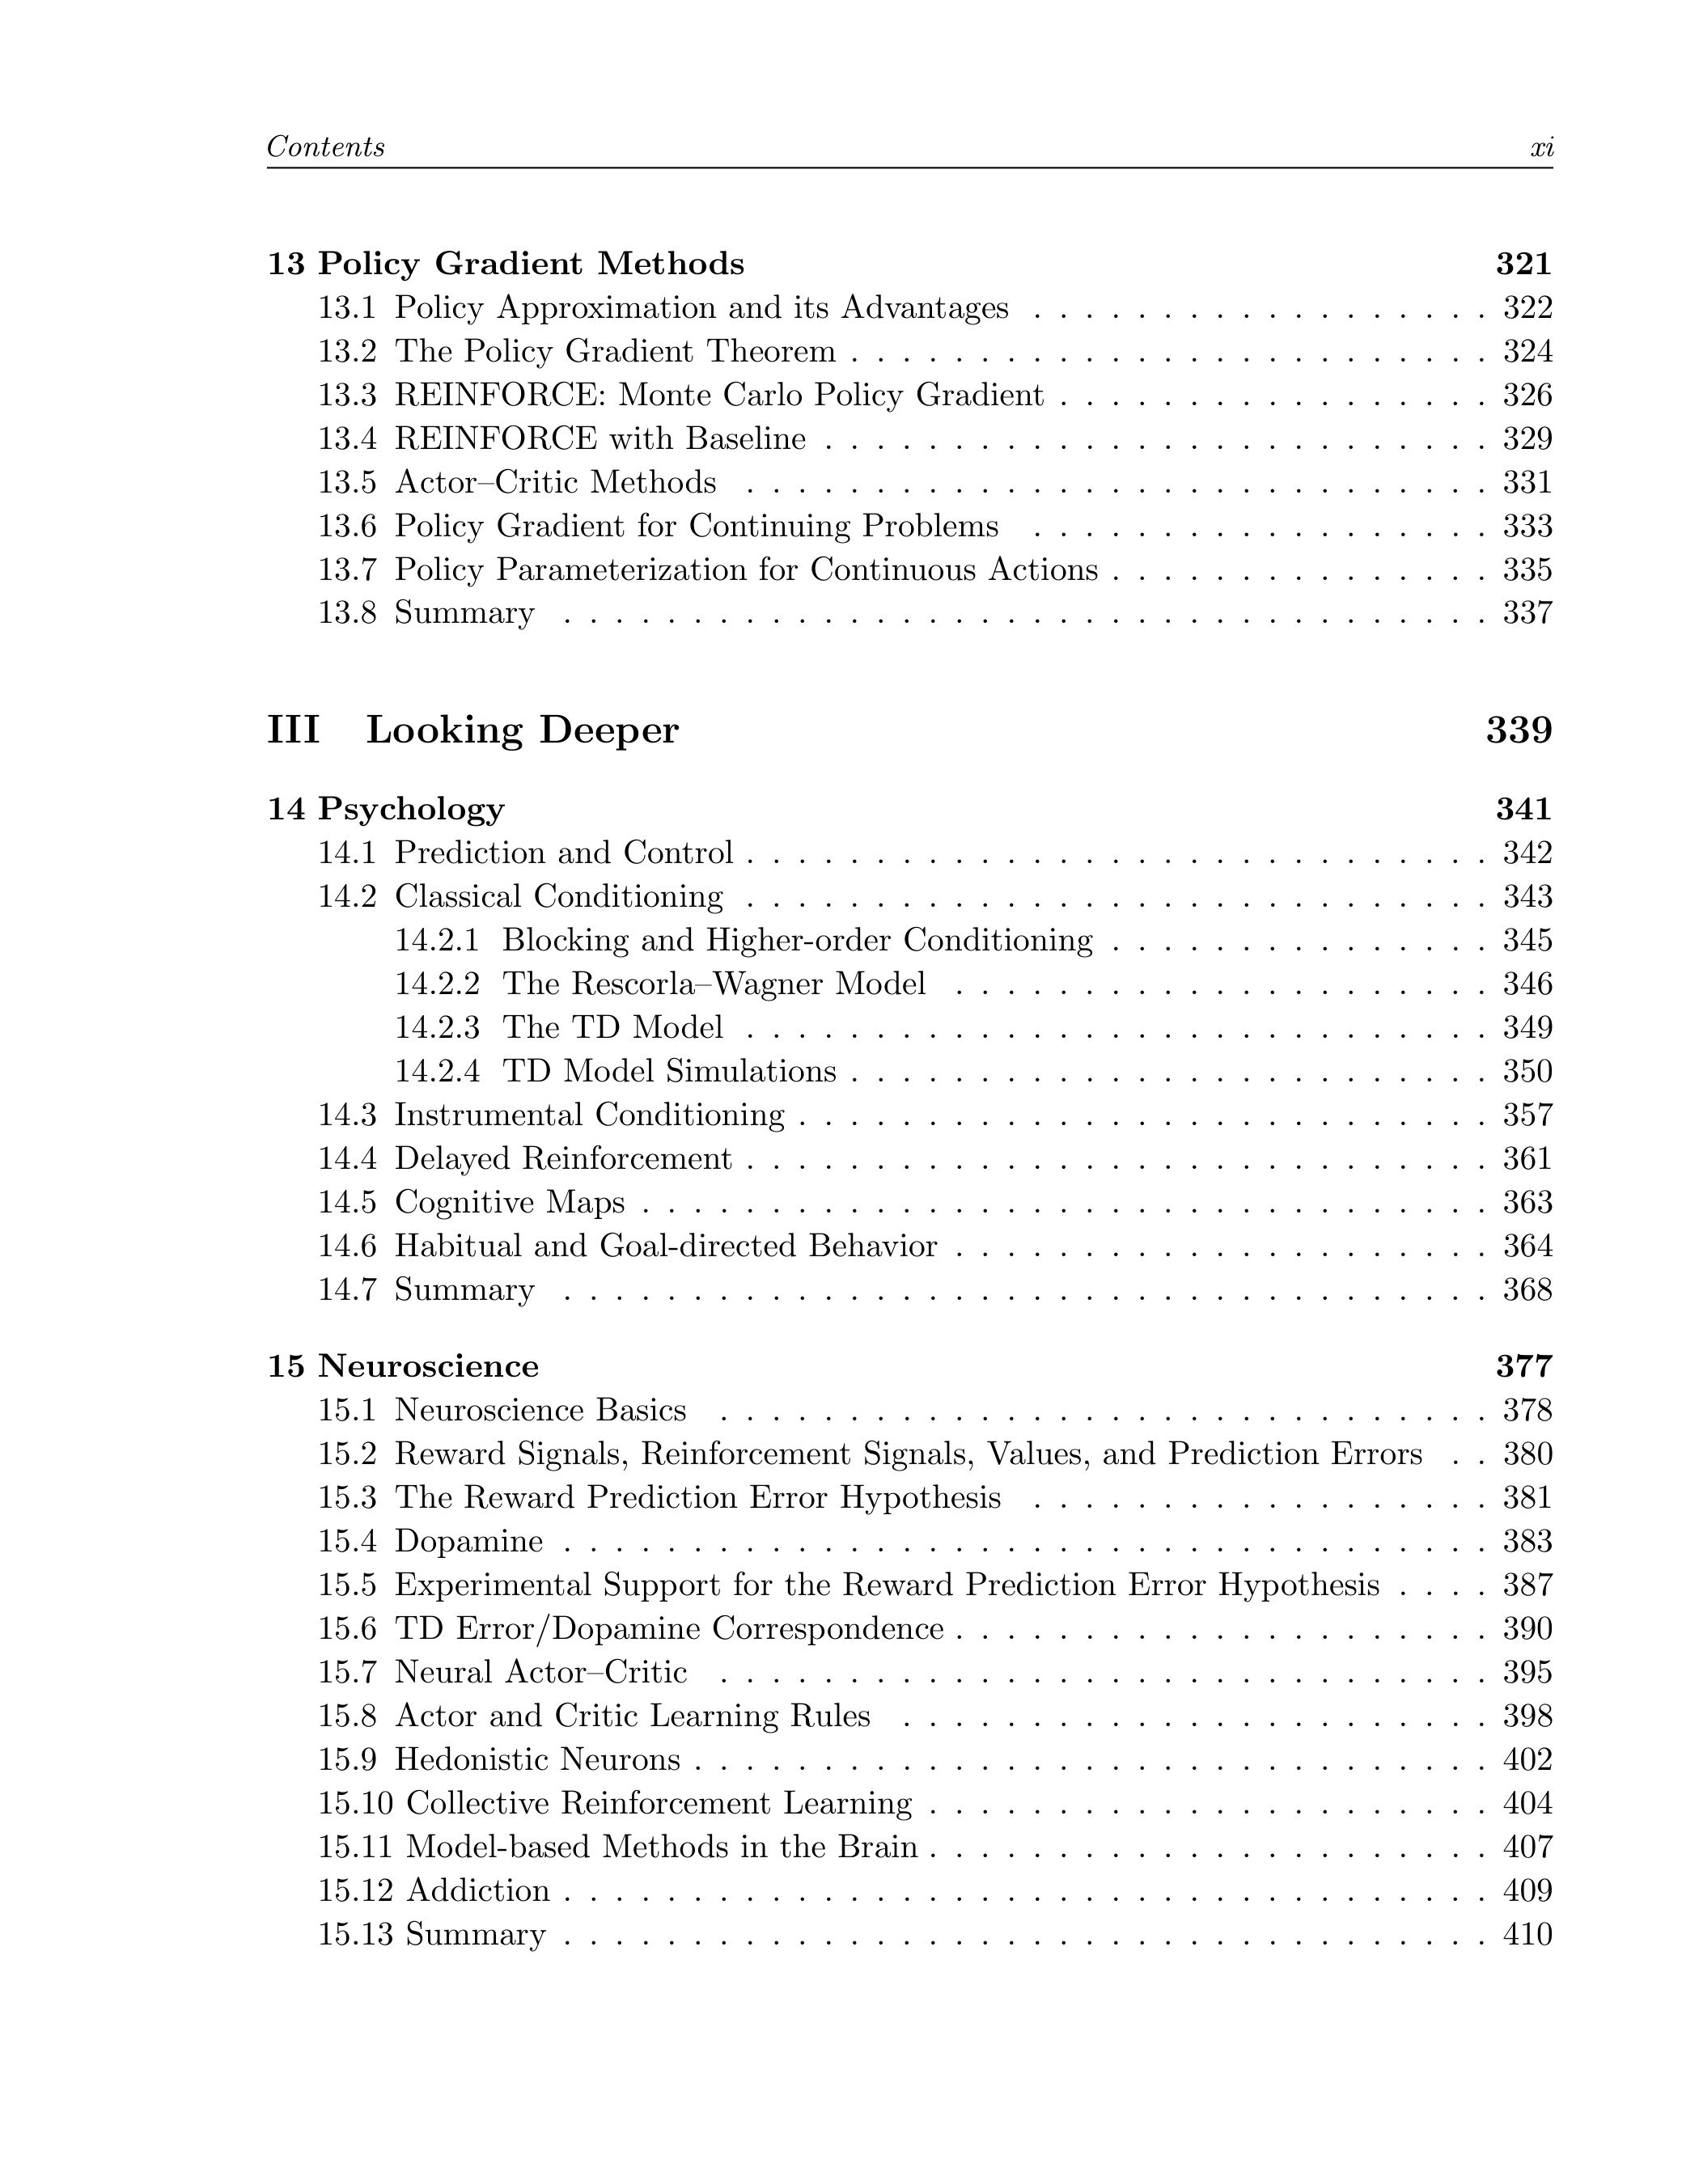

In [24]:
import fitz
from PIL import Image
import io

doc = fitz.open(pdf_path)
page = doc[10]
pix = page.get_pixmap(dpi=300)
img = Image.open(io.BytesIO(pix.tobytes("png")))

img

In [25]:
layout = lp([img])

Recognizing Layout: 100%|██████████| 1/1 [00:00<00:00,  4.11it/s]


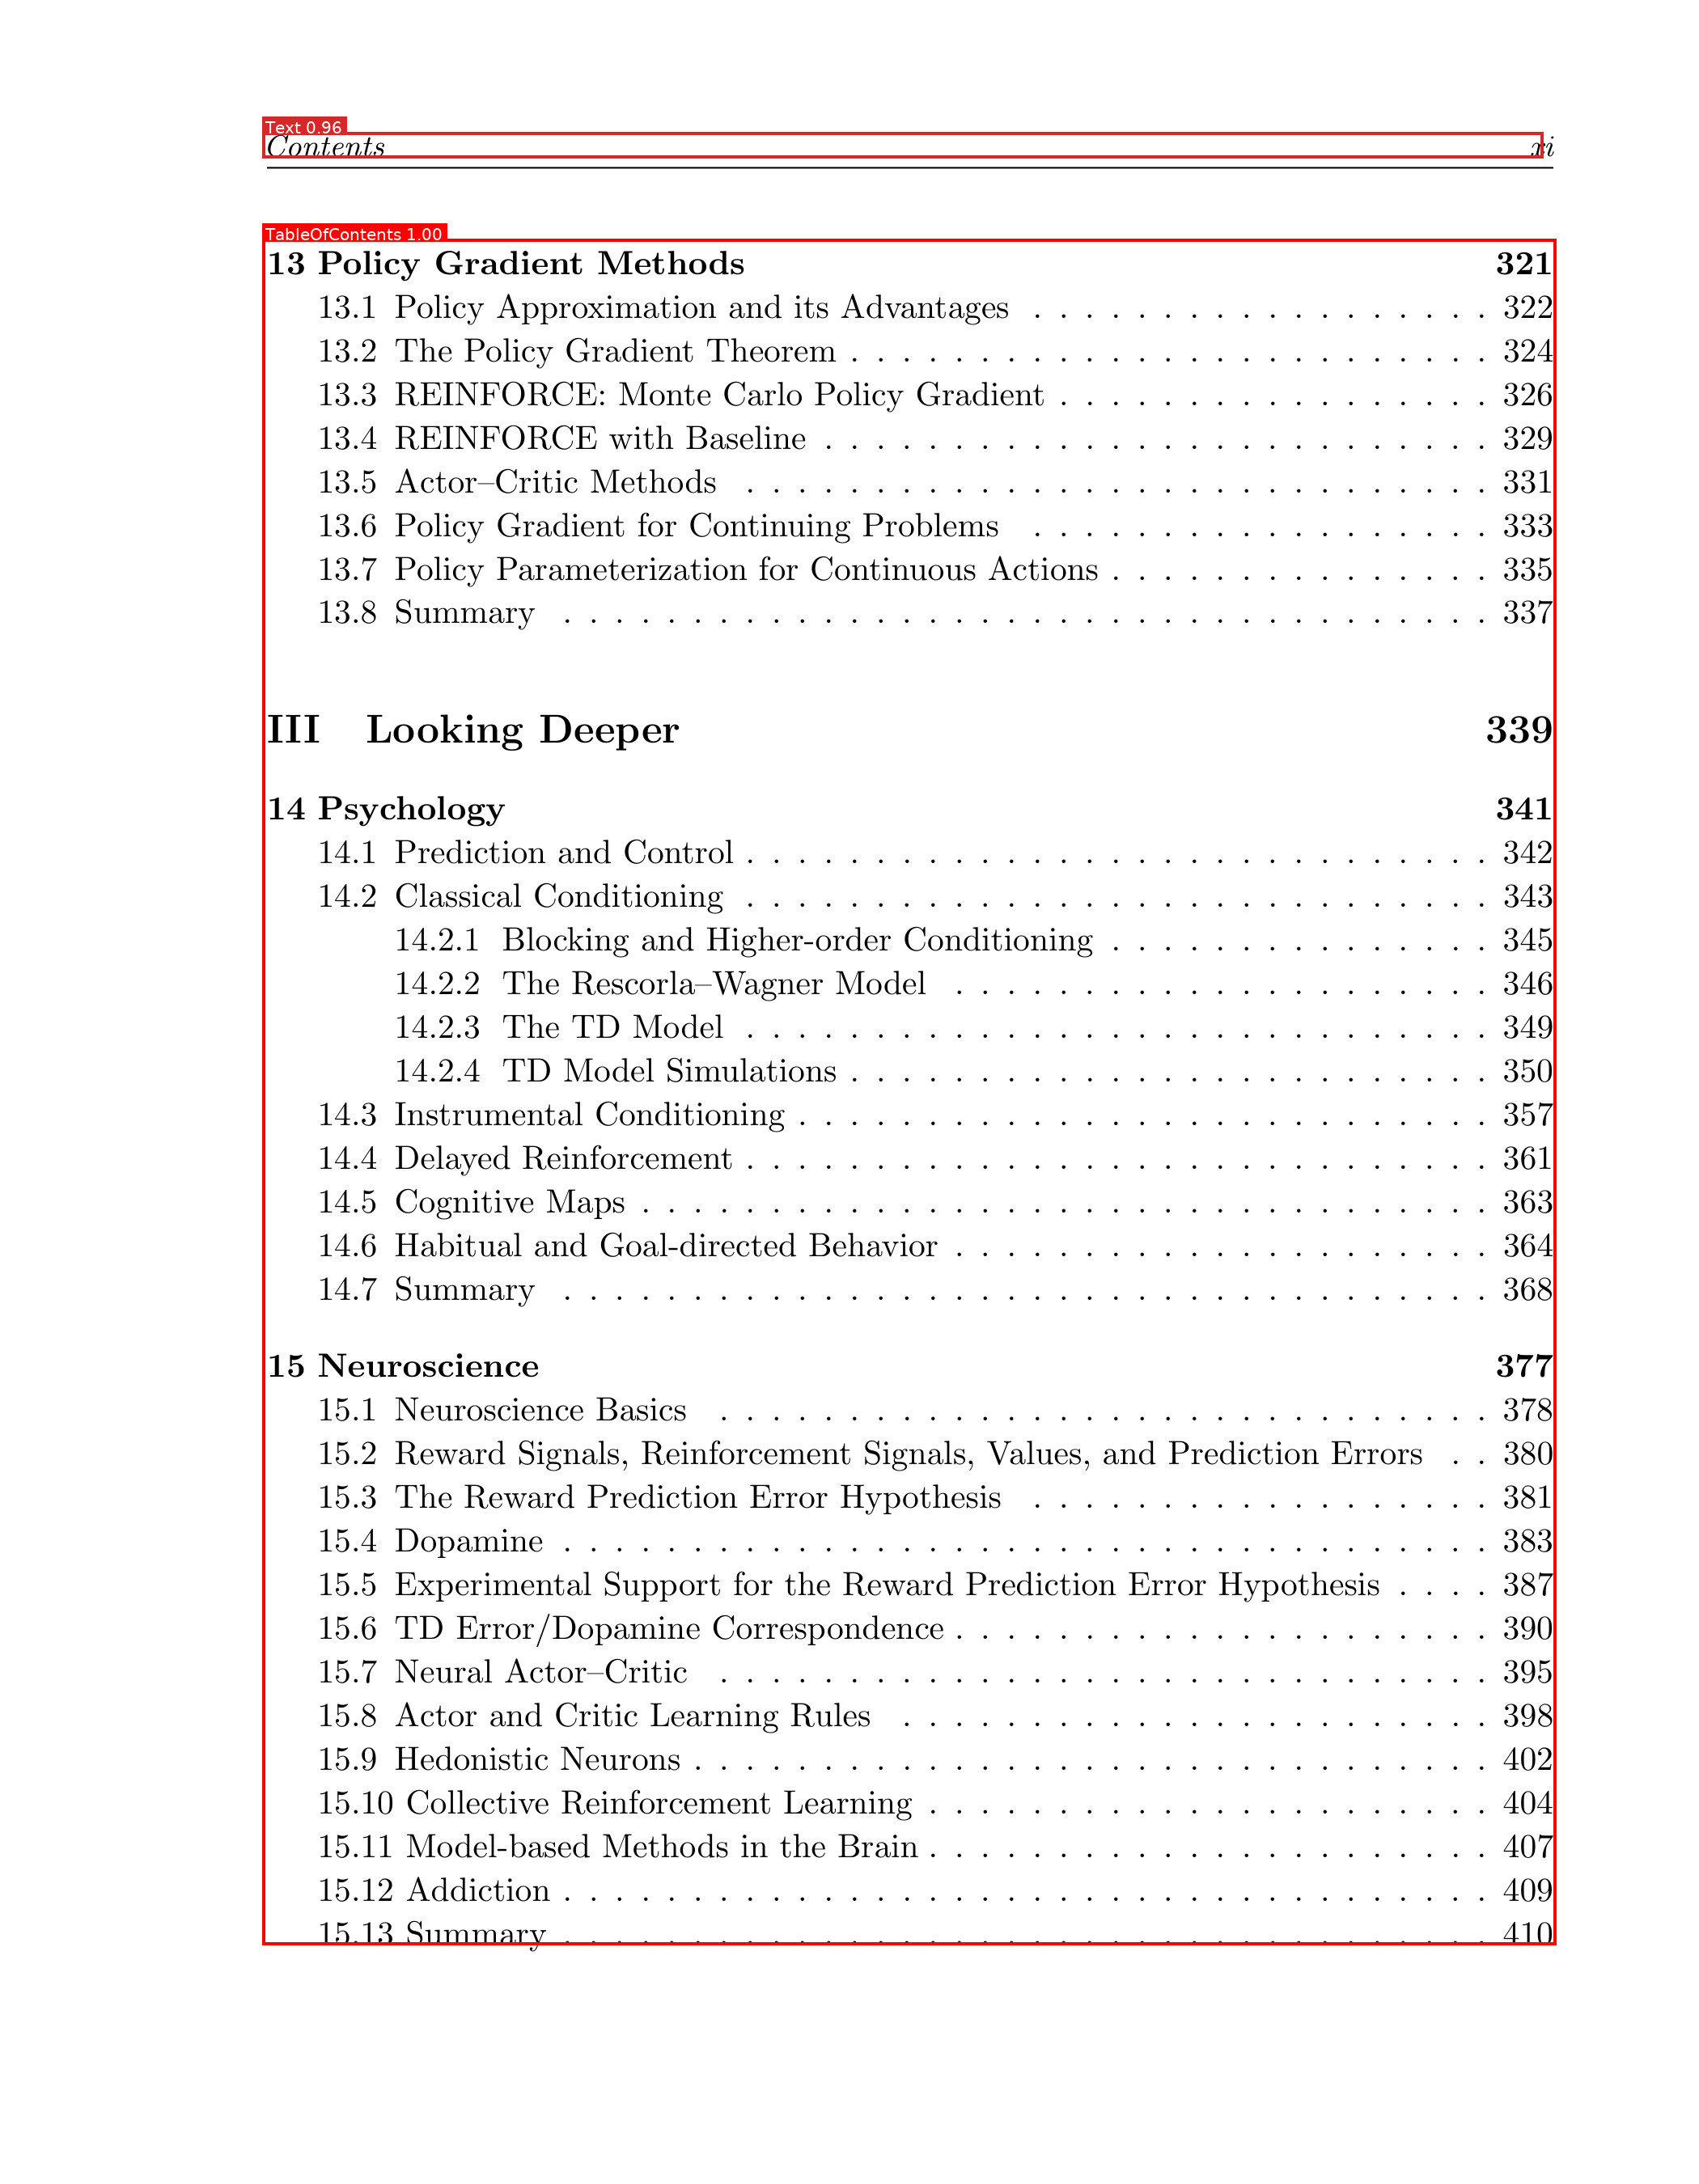

In [26]:
annotated_result = annotate_layout(img, layout[0])

annotated_result

In [20]:
import rich

rich.print(layout)

[
    LayoutResult(
        bboxes=[
            LayoutBox(
                polygon=[[41.015625, 0.0], [2108.203125, 0.0], [2108.203125, 2700.0], [41.015625, 2700.0]],
                confidence=0.7986364364624023,
                label='Figure',
                position=0,
                top_k={
                    'Figure': 0.004190859384834766,
                    'Picture': 0.10808368772268295,
                    'SectionHeader': 0.06555607169866562,
                    'Text': 0.02195853367447853
                },
                bbox=[41.015625, 0.0, 2108.203125, 2700.0]
            )
        ],
        image_bbox=[0.0, 0.0, 2100.0, 2700.0],
        sliced=False
    )
]